# Resource-Management & Communications Performance (F1 / F2 / F3)

OpenMATB transparency study — objective performance on the two **non-automated**
tasks (resource management and communications), compared across the three
explanation forms. This is the primary objective measure for **H4** (saved
attention is redeployed: performance on non-automated tasks is higher under
F2/F3 than under F1).

> **Status:** pipeline prepared on pilot data; re-run unchanged once P01–P10 are collected.
>
> **Data source:** logs are read from `analysis/session_logs/` (recursively). Only sessions placed in that folder are analysed.

## How performance is measured (literature)

**Resource management.** Two depleting tanks (A, B) must be held near a target of
2500 units. Performance is the **root-mean-square deviation (RMSD)** of tank level
from target, and the **proportion of time within tolerance** (±500 → 2000–3000).
- Cegarra, J., Valéry, B., Avril, E., Calmettes, C., & Navarro, J. (2020).
  *OpenMATB: A Multi-Attribute Task Battery…* Behavior Research Methods, 52, 1980–1990.
- Santiago-Espada, Y., Myer, R. R., Latorella, K. A., & Comstock, J. R. (2011).
  *The Multi-Attribute Task Battery II (MATB-II) Software… User's Guide.* NASA/TM-2011-217164.
- Comstock, J. R., & Arnegard, R. J. (1992). *The Multi-Attribute Task Battery…* NASA TM-104174.

**Communications.** Respond to own-call-sign radio requests (set the named radio to
the requested frequency), ignore distractor call signs. Scored as **response
accuracy** and **response time** within a signal-detection framing
(hit / miss / false alarm; OpenMATB also distinguishes wrong-radio / wrong-frequency
errors). Response time is the latency from end-of-call to a validated response, in
milliseconds, reported on hits only.
- Cegarra et al. (2020), as above.


In [1]:
import sys
from pathlib import Path

# Make the matb_analysis package importable when running from notebooks/.
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matb_analysis.aggregate import build_metrics_table
from matb_analysis.discovery import find_study_sessions

sns.set_theme(style="whitegrid")
FORM_ORDER = ["F1", "F2", "F3"]
OUT = Path.cwd().parent / "outputs"
OUT.mkdir(exist_ok=True)


## 1. Load sessions and build the tidy metrics table

In [2]:
from matb_analysis.discovery import DEFAULT_SESSIONS_DIR

sessions = find_study_sessions()
print(f"Reading logs from: {DEFAULT_SESSIONS_DIR}")
print(f"Discovered {len(sessions)} study session(s):")
for s in sessions:
    print(f"  {s.path.name:32s} participant={s.participant:5s} kind={s.scenario_kind}")
if not sessions:
    print()
    print("No logs yet. Copy the relevant OpenMATB session CSVs into")
    print("analysis/session_logs/ and re-run this notebook.")

table = build_metrics_table(sessions)
table.to_csv(OUT / "metrics_by_block.csv", index=False)
table

Reading logs from: C:\Projects\HumanCenteredAI\analysis\session_logs
Discovered 1 study session(s):
  24_260530_151227.csv             participant=P02   kind=full


,participant,form,block,session_file,rmsd_a,rmsd_b,rmsd_mean,mad_a,mad_b,pct_in_tolerance_a,...,n_miss,n_fa,n_bad_radio,n_bad_freq,n_bad_radio_freq,accuracy,miss_rate,fa_count,mean_rt_hit,mean_abs_freq_dev
0,P02,F1,A,24_260530_151227.csv,189.276870,185.124535,187.200702,151.080000,162.773333,80.000000,...,7,0,0,0,0,0.0,1.0,0,NaN,NaN
1,P02,F3,B,24_260530_151227.csv,149.613453,118.169818,133.891636,128.317881,90.211921,94.039735,...,6,0,0,0,0,0.0,1.0,0,NaN,NaN
2,P02,F2,C,24_260530_151227.csv,157.288658,152.769965,155.029311,128.834437,117.456954,88.741722,...,6,0,0,0,0,0.0,1.0,0,NaN,NaN


## 1b. Session validation

Cross-checks each session's realised structure against the study design:
briefing form vs. panel form, panel block vs. the gauges that actually failed,
and the realised (form, block) order vs. the participant's Latin-square row.
Any `ok = False` row must be resolved before trusting that session's numbers.

In [3]:
from matb_analysis.validation import validate_sessions

report = validate_sessions(sessions)
n_bad = int((~report["ok"]).sum()) if not report.empty else 0
print(f"{len(report)} session(s) validated; {n_bad} with issues.")
report

1 session(s) validated; 0 with issues.


,session_file,participant,kind,ok,n_blocks,realized,expected,issues
0,24_260530_151227.csv,P02,full,True,3,"[(F1, A), (F3, B), (F2, C)]","[(F1, A), (F3, B), (F2, C)]",


## 2. Resource management by form

RMSD from the 2500 target (lower = better) and percent time in tolerance
(higher = better).

In [4]:
resman_cols = ["rmsd_mean", "pct_in_tolerance_mean", "mad_a", "mad_b",
               "mean_excursion_sec", "n_excursions"]
resman_desc = (table.groupby("form")[resman_cols]
                    .agg(["mean", "median", "std"])
                    .reindex(FORM_ORDER))
resman_desc


rmsd_mean                 pct_in_tolerance_mean                 \
            mean      median std                  mean     median std   
form                                                                    
F1    187.200702  187.200702 NaN             79.666667  79.666667 NaN   
F2    155.029311  155.029311 NaN             88.741722  88.741722 NaN   
F3    133.891636  133.891636 NaN             93.708609  93.708609 NaN   

           mad_a                       mad_b                  \
            mean      median std        mean      median std   
form                                                           
F1    151.080000  151.080000 NaN  162.773333  162.773333 NaN   
F2    128.834437  128.834437 NaN  117.456954  117.456954 NaN   
F3    128.317881  128.317881 NaN   90.211921   90.211921 NaN   

     mean_excursion_sec            n_excursions             
                   mean median std         mean median std  
form                                                        
F1                 32.0   32.0 NaN          3.0    3.0 NaN  
F2                 34.0   34.0 NaN          2.0    2.0 NaN  
F3                 32.0   32.0 NaN          2.0    2.0 NaN

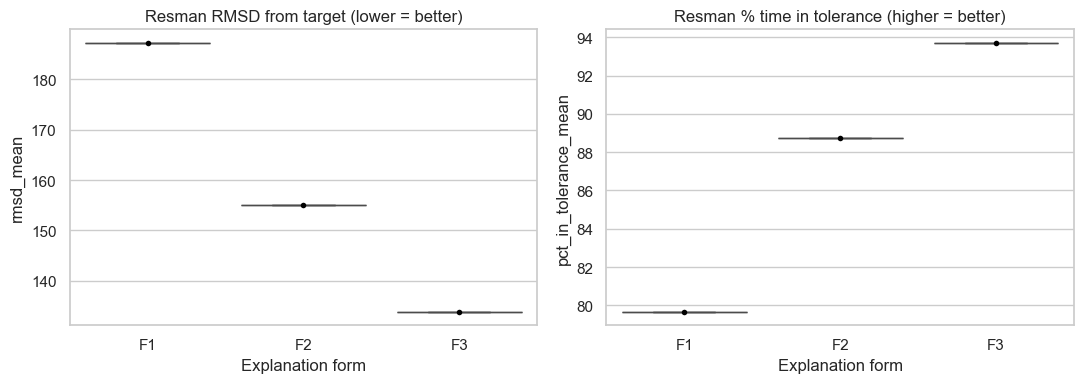

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(
    axes,
    ["rmsd_mean", "pct_in_tolerance_mean"],
    ["Resman RMSD from target (lower = better)",
     "Resman % time in tolerance (higher = better)"],
):
    sns.boxplot(data=table, x="form", y=col, order=FORM_ORDER, ax=ax)
    sns.stripplot(data=table, x="form", y=col, order=FORM_ORDER,
                  color="black", size=4, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Explanation form")
fig.tight_layout()
fig.savefig(OUT / "resman_by_form.png", dpi=150)
plt.show()


## 3. Communications by form

Accuracy (hits / signal trials), response time on hits (ms), false-alarm count,
and frequency-setting error.

In [6]:
comms_cols = ["accuracy", "miss_rate", "fa_count", "mean_rt_hit",
              "mean_abs_freq_dev", "n_signal"]
comms_desc = (table.groupby("form")[comms_cols]
                   .agg(["mean", "median", "std"])
                   .reindex(FORM_ORDER))
comms_desc


accuracy            miss_rate            fa_count            mean_rt_hit  \
         mean median std      mean median std     mean median std        mean   
form                                                                            
F1        0.0    0.0 NaN       1.0    1.0 NaN      0.0    0.0 NaN         NaN   
F2        0.0    0.0 NaN       1.0    1.0 NaN      0.0    0.0 NaN         NaN   
F3        0.0    0.0 NaN       1.0    1.0 NaN      0.0    0.0 NaN         NaN   

                mean_abs_freq_dev            n_signal             
     median std              mean median std     mean median std  
form                                                              
F1      NaN NaN               NaN    NaN NaN      7.0    7.0 NaN  
F2      NaN NaN               NaN    NaN NaN      6.0    6.0 NaN  
F3      NaN NaN               NaN    NaN NaN      6.0    6.0 NaN

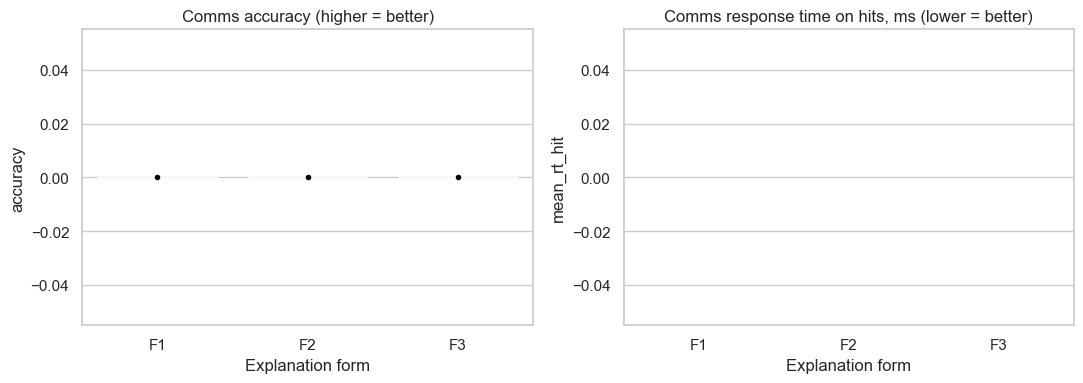

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(
    axes,
    ["accuracy", "mean_rt_hit"],
    ["Comms accuracy (higher = better)",
     "Comms response time on hits, ms (lower = better)"],
):
    sns.barplot(data=table, x="form", y=col, order=FORM_ORDER,
                errorbar="sd", ax=ax)
    sns.stripplot(data=table, x="form", y=col, order=FORM_ORDER,
                  color="black", size=4, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Explanation form")
fig.tight_layout()
fig.savefig(OUT / "comms_by_form.png", dpi=150)
plt.show()


## 4. Summary table (H4)

One row per form with the headline non-automated-task measures. H4 predicts
F2/F3 ≥ F1 on accuracy and % in tolerance, and ≤ on RMSD and response time.

In [8]:
summary = (table.groupby("form")[
              ["rmsd_mean", "pct_in_tolerance_mean", "accuracy",
               "mean_rt_hit", "fa_count"]]
              .mean()
              .reindex(FORM_ORDER)
              .round(2))
summary.to_csv(OUT / "h4_summary_by_form.csv")
summary


,rmsd_mean,pct_in_tolerance_mean,accuracy,mean_rt_hit,fa_count
form,,,,,
F1,187.20,79.67,0.0,NaN,0.0
F2,155.03,88.74,0.0,NaN,0.0
F3,133.89,93.71,0.0,NaN,0.0


## 5. Inferential tests — to add when N is adequate

Deliberately omitted now (small pilot N). When P01–P10 are collected, add
within-subject tests across the three forms per metric (e.g. Friedman omnibus +
Wilcoxon signed-rank post-hoc, non-parametric), with assumptions stated. The tidy
table above (`outputs/metrics_by_block.csv`) is the input for those tests.
